Dataset shape: (130663, 17)

First few rows:
  artist_name                track_id  \
0          YG  2RM4jf1Xa9zPgMGRDiht8O   
1          YG  1tHDG53xJNGsItRA3vfVgs   
2       R3HAB  6Wosx2euFPMT14UXiWudMy   
3  Chris Cooq  3J2Jpw61sO7l6Hc7qdYV91   
4  Chris Cooq  2jbYvQCyPgX3CdmAzeVeuS   

                                       track_name  acousticness  danceability  \
0  Big Bank feat. 2 Chainz, Big Sean, Nicki Minaj      0.005820         0.743   
1                    BAND DRUM (feat. A$AP Rocky)      0.024400         0.846   
2                                   Radio Silence      0.025000         0.603   
3                                         Lactose      0.029400         0.800   
4                             Same - Original mix      0.000035         0.783   

   duration_ms  energy  instrumentalness  key  liveness  loudness  mode  \
0       238373   0.339             0.000    1    0.0812    -7.678     1   
1       214800   0.557             0.000    8    0.2860    -7.259     1

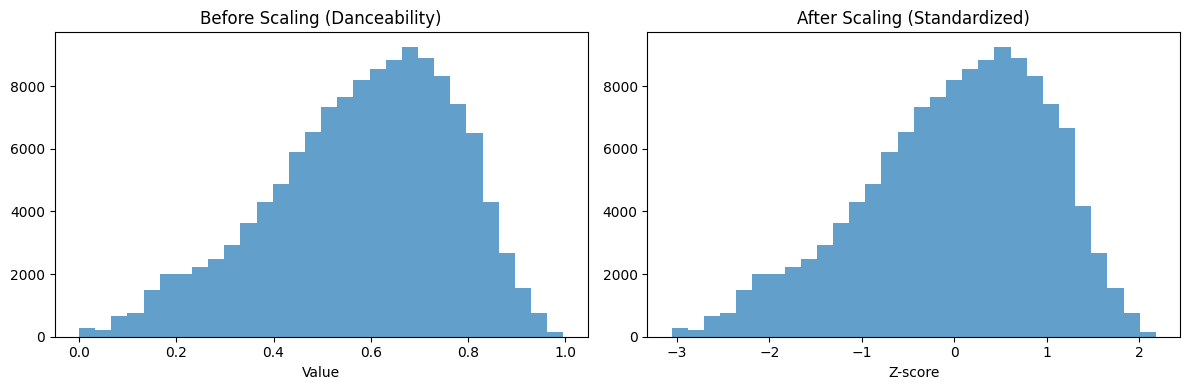

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
import warnings
warnings.filterwarnings('ignore')

# Load dataset
df = pd.read_csv('SpotifyAudioFeaturesApril2019.csv')

print("Dataset shape:", df.shape)
print("\nFirst few rows:")
print(df.head())

print("\nColumns:")
print(df.columns.tolist())

print("\nData types:")
print(df.dtypes)

print("\nMissing values:")
print(df.isnull().sum())

# Select audio features for clustering
audio_features = [
    'danceability',     # How suitable for dancing (0-1)
    'energy',           # Intensity and activity (0-1)
    'key',              # Key of the song (0-11)
    'loudness',         # Overall loudness in dB (-60 to 0)
    'mode',             # Major (1) or minor (0)
    'speechiness',      # Presence of spoken words (0-1)
    'acousticness',     # Acoustic vs electronic (0-1)
    'instrumentalness', # Vocal content (0-1)
    'liveness',         # Live audience presence (0-1)
    'valence',          # Musical positiveness (0-1)
    'tempo',            # Beats per minute
    'duration_ms',      # Length in milliseconds
    'time_signature'    # Beats per bar (3-7)
]

# Check which features exist in your dataset
available_features = [f for f in audio_features if f in df.columns]
print(f"Available features: {len(available_features)}")
print(available_features)

# Extract features
X = df[available_features].copy()

# Handle missing values
X = X.fillna(X.median())

print(f"\nFeature matrix shape: {X.shape}")

# Scale features (CRITICAL for K-Means!)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Before scaling:")
print(f"Mean: {X.mean().mean():.2f}, Std: {X.std().mean():.2f}")

print("\nAfter scaling:")
print(f"Mean: {X_scaled.mean():.2f}, Std: {X_scaled.std():.2f}")

# Visualize distributions before/after
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Before scaling
axes[0].hist(X['danceability'], bins=30, alpha=0.7)
axes[0].set_title('Before Scaling (Danceability)')
axes[0].set_xlabel('Value')

# After scaling (using first feature)
axes[1].hist(X_scaled[:, 0], bins=30, alpha=0.7)
axes[1].set_title('After Scaling (Standardized)')
axes[1].set_xlabel('Z-score')

plt.tight_layout()
plt.show()

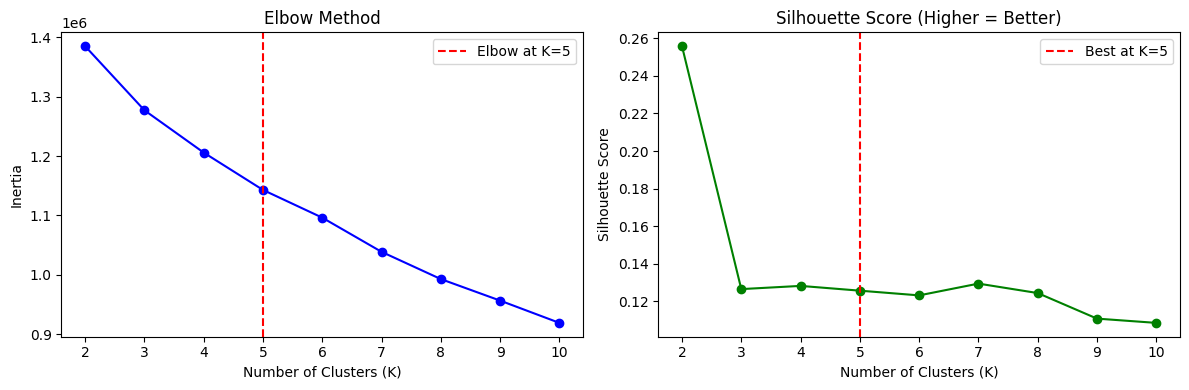

Silhouette Scores:
K=2: 0.256
K=3: 0.127
K=4: 0.128
K=5: 0.126
K=6: 0.123
K=7: 0.129
K=8: 0.124
K=9: 0.111
K=10: 0.109


In [6]:
# Elbow Method
inertias = []
silhouette_scores = []
K_range = range(2, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertias.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(X_scaled, kmeans.labels_))

# Plot Elbow Curve
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

# Elbow Method
ax1.plot(K_range, inertias, 'bo-')
ax1.set_xlabel('Number of Clusters (K)')
ax1.set_ylabel('Inertia')
ax1.set_title('Elbow Method')
ax1.axvline(x=5, color='r', linestyle='--', label='Elbow at K=5')
ax1.legend()

# Silhouette Score
ax2.plot(K_range, silhouette_scores, 'go-')
ax2.set_xlabel('Number of Clusters (K)')
ax2.set_ylabel('Silhouette Score')
ax2.set_title('Silhouette Score (Higher = Better)')
ax2.axvline(x=5, color='r', linestyle='--', label='Best at K=5')
ax2.legend()

plt.tight_layout()
plt.show()

print("Silhouette Scores:")
for k, score in zip(K_range, silhouette_scores):
    print(f"K={k}: {score:.3f}")

In [7]:
# Choose optimal K (let's use K=5)
optimal_k = 5
kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)

# Train model
clusters = kmeans.fit_predict(X_scaled)

# Add cluster labels to dataframe
df['cluster'] = clusters

print(f"Clusters assigned: {clusters[:10]}")
print(f"\nCluster distribution:")
print(df['cluster'].value_counts().sort_index())

Clusters assigned: [4 4 3 3 1 3 3 4 1 1]

Cluster distribution:
cluster
0     9099
1    47969
2    24687
3    33832
4    15076
Name: count, dtype: int64


In [8]:
# Calculate cluster profiles
cluster_profiles = df.groupby('cluster')[available_features].mean()

print("Cluster Centers (Audio Feature Averages):")
print(cluster_profiles.round(3))

# Add cluster names based on characteristics
cluster_names = {
    0: '🎵 Chill Acoustic',
    1: '💃 Dance Party',
    2: '🎸 Energetic Rock',
    3: '🎹 Study/Focus',
    4: '😊 Happy Pop'
}

df['cluster_name'] = df['cluster'].map(cluster_names)

print("\nCluster Interpretation:")
for cluster in range(optimal_k):
    print(f"\n{cluster_names[cluster]}:")
    profile = cluster_profiles.loc[cluster]
    print(f"  - Danceability: {profile['danceability']:.2f}")
    print(f"  - Energy: {profile['energy']:.2f}")
    print(f"  - Valence: {profile['valence']:.2f}")
    print(f"  - Acousticness: {profile['acousticness']:.2f}")

Cluster Centers (Audio Feature Averages):
         danceability  energy    key  loudness   mode  speechiness  \
cluster                                                              
0               0.482   0.745  5.299    -8.627  0.628        0.118   
1               0.627   0.654  4.755    -7.311  1.000        0.072   
2               0.376   0.189  4.933   -19.743  0.674        0.053   
3               0.643   0.670  6.164    -7.351  0.000        0.088   
4               0.696   0.590  5.106    -9.150  0.603        0.387   

         acousticness  instrumentalness  liveness  valence    tempo  \
cluster                                                               
0               0.215             0.223     0.657    0.385  121.400   
1               0.228             0.143     0.156    0.502  123.544   
2               0.845             0.575     0.147    0.247  104.975   
3               0.204             0.162     0.161    0.476  122.624   
4               0.272             0.047  

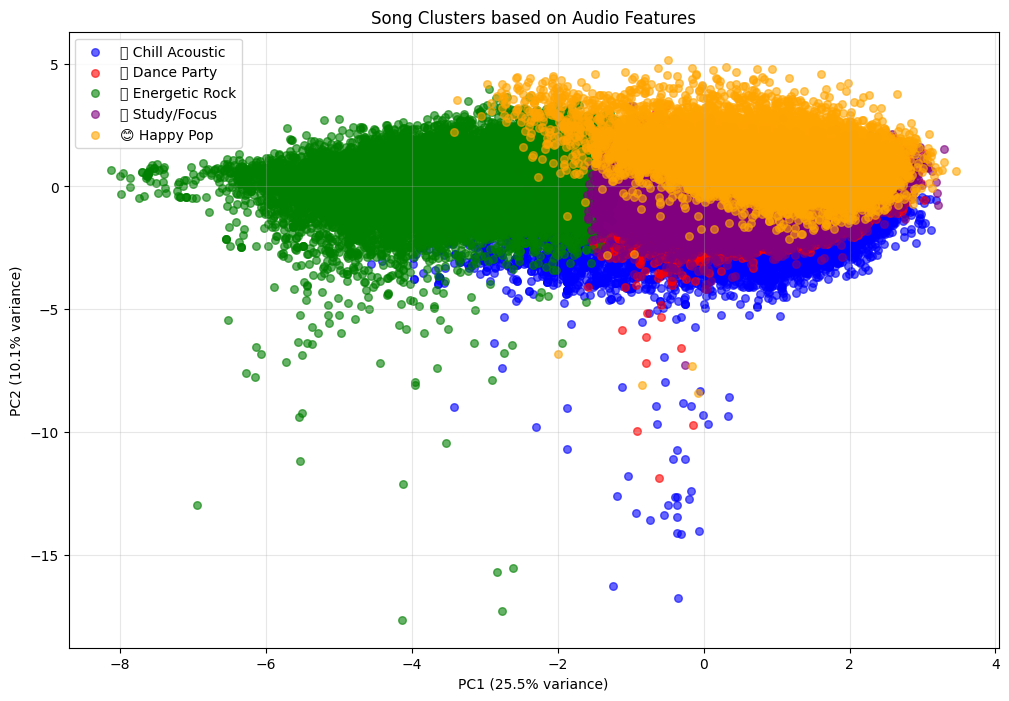

In [9]:
# Reduce to 2D for visualization
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# Plot clusters
plt.figure(figsize=(12, 8))

colors = ['blue', 'red', 'green', 'purple', 'orange']
for cluster in range(optimal_k):
    mask = df['cluster'] == cluster
    plt.scatter(X_pca[mask, 0], X_pca[mask, 1], 
                c=colors[cluster], label=cluster_names[cluster], 
                alpha=0.6, s=30)

plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%} variance)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%} variance)')
plt.title('Song Clusters based on Audio Features')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [10]:
def recommend_similar_songs(song_name, df, kmeans, scaler, n_recommendations=5):
    """
    Recommend songs similar to a given song
    """
    # Find the song
    song = df[df['name'] == song_name]
    
    if len(song) == 0:
        print(f"Song '{song_name}' not found!")
        return None
    
    # Get song's cluster
    song_cluster = song['cluster'].values[0]
    
    # Get all songs in same cluster
    similar_songs = df[df['cluster'] == song_cluster].copy()
    
    # Remove the input song
    similar_songs = similar_songs[similar_songs['name'] != song_name]
    
    # Get top N recommendations
    recommendations = similar_songs.head(n_recommendations)
    
    print(f"\n🎵 Songs similar to '{song_name}' (from {song['cluster_name'].values[0]}):")
    print("-" * 50)
    for idx, row in recommendations.iterrows():
        print(f"  • {row['name']} by {row.get('artists', 'Unknown')}")
    
    return recommendations

# Example usage (adjust column names based on your dataset)
if 'name' in df.columns:
    # Replace with an actual song name from your dataset
    example_song = df['name'].iloc[0]
    recommend_similar_songs(example_song, df, kmeans, scaler)
    

In [11]:
def create_mood_playlist(mood, df, n_songs=20):
    """
    Create playlist based on mood description
    """
    mood_features = {
        'party': {'danceability': 0.7, 'energy': 0.7, 'valence': 0.6},
        'chill': {'acousticness': 0.6, 'energy': 0.3, 'danceability': 0.3},
        'workout': {'energy': 0.8, 'tempo': 130, 'valence': 0.5},
        'sad': {'valence': 0.3, 'energy': 0.3, 'danceability': 0.3},
        'happy': {'valence': 0.8, 'danceability': 0.6, 'energy': 0.6},
        'focus': {'instrumentalness': 0.5, 'speechiness': 0.1, 'energy': 0.3}
    }
    
    if mood not in mood_features:
        print(f"Mood '{mood}' not found. Choose from: {list(mood_features.keys())}")
        return None
    
    # Get target features for mood
    target = mood_features[mood]
    
    # Score each song based on how well it matches the mood
    scores = []
    for idx, row in df.iterrows():
        score = 0
        for feature, target_value in target.items():
            if feature in row:
                # Calculate similarity to target
                diff = abs(row[feature] - target_value)
                score += (1 - diff)  # Lower difference = higher score
        scores.append(score)
    
    df_temp = df.copy()
    df_temp['mood_score'] = scores
    
    # Get top songs
    playlist = df_temp.nlargest(n_songs, 'mood_score')
    
    print(f"\n🎧 {mood.upper()} PLAYLIST ({n_songs} songs):")
    print("-" * 50)
    for idx, row in playlist.iterrows():
        print(f"  • {row.get('name', 'Unknown')}" + 
              (f" by {row.get('artists', 'Unknown')}" if 'artists' in row else ""))
    
    return playlist

# Create example playlists
create_mood_playlist('party', df, 10)
create_mood_playlist('chill', df, 10)


🎧 PARTY PLAYLIST (10 songs):
--------------------------------------------------
  • Unknown
  • Unknown
  • Unknown
  • Unknown
  • Unknown
  • Unknown
  • Unknown
  • Unknown
  • Unknown
  • Unknown

🎧 CHILL PLAYLIST (10 songs):
--------------------------------------------------
  • Unknown
  • Unknown
  • Unknown
  • Unknown
  • Unknown
  • Unknown
  • Unknown
  • Unknown
  • Unknown
  • Unknown


,artist_name,track_id,track_name,acousticness,danceability,duration_ms,energy,instrumentalness,key,liveness,loudness,mode,speechiness,tempo,time_signature,valence,popularity,cluster,cluster_name,mood_score
82736,Still Haze,0SVUqYA9lRn8v3jTsDvLNx,Rift,0.597,0.305,257391,0.312,0.009660,1,0.0871,-12.826,0,0.3960,56.674,3,0.1720,17,2,🎸 Energetic Rock,2.980
27663,Jeff Carl,5St8jW5BVKPqocrSBu6n03,Comeback Song,0.608,0.307,217284,0.293,0.000015,4,0.1060,-11.616,1,0.0289,134.937,4,0.1140,12,2,🎸 Energetic Rock,2.978
59858,Lee DeWyze,7p8hSE39zuLP7hjQjduMTw,Carry Us Through,0.581,0.302,176211,0.305,0.082900,7,0.1100,-9.355,1,0.0438,187.080,3,0.3470,19,1,💃 Dance Party,2.974
118524,Neil Diamond,2h5vXW7W1Prfj1knWwoPX1,Another Day (That Time Forgot),0.603,0.324,371053,0.298,0.015900,9,0.1010,-13.928,1,0.0296,173.688,4,0.4690,14,1,💃 Dance Party,2.971
119443,Johann Sebastian Bach,0ZsCrrKTk5TVxneUYgPfxz,"Aria variata in A Minor, BWV 989 ""Alla maniera...",0.606,0.275,96413,0.293,0.884000,8,0.1480,-20.169,1,0.0375,124.677,4,0.7510,7,2,🎸 Energetic Rock,2.962
19947,Editors,4M9fLPjjjO5QnUHuZk9SuW,No Sound but the Wind,0.581,0.282,267464,0.289,0.001710,4,0.0890,-11.560,1,0.0327,175.913,4,0.1110,52,2,🎸 Energetic Rock,2.952
39727,Perpetuum Jazzile,2gBnA2xgkRVeurLyhMoefg,Last Train Home,0.562,0.308,250907,0.296,0.514000,8,0.0950,-10.303,1,0.0296,147.797,4,0.0398,0,2,🎸 Energetic Rock,2.950
51381,Depher,3SCWw5WPeAm44Atd6fgqtJ,Crazy Feeling,0.573,0.317,106079,0.306,0.970000,10,0.1060,-6.469,0,0.0307,94.916,4,0.2850,0,2,🎸 Energetic Rock,2.950
111790,Au/Ra,3JODhv0i37KChbC4OPEoAd,Ultraviolet,0.591,0.276,229162,0.283,0.000138,5,0.0792,-8.588,0,0.0378,172.942,4,0.2220,48,3,🎹 Study/Focus,2.950
79771,Ronald Nelson,3nOnbKdytQ53jEuaX6FBxn,Peacefulness Without Chaotic Intro - Original Mix,0.607,0.285,99305,0.270,0.437000,0,0.1330,-10.160,1,0.0405,119.561,5,0.2020,2,2,🎸 Energetic Rock,2.948


In [12]:
# Save the model and scaler
import joblib

# Save model components
joblib.dump(kmeans, 'spotify_kmeans_model.pkl')
joblib.dump(scaler, 'spotify_scaler.pkl')
joblib.dump(pca, 'spotify_pca.pkl')

print("✅ Model saved successfully!")

# Evaluate cluster quality
print("\n📊 Model Evaluation:")
print(f"Number of clusters: {optimal_k}")
print(f"Silhouette Score: {silhouette_score(X_scaled, clusters):.3f}")
print(f"Inertia: {kmeans.inertia_:.0f}")

# Check cluster sizes
cluster_sizes = df['cluster'].value_counts()
print(f"\nCluster sizes:")
for cluster in range(optimal_k):
    size = cluster_sizes[cluster]
    pct = size / len(df) * 100
    print(f"  {cluster_names[cluster]}: {size} songs ({pct:.1f}%)")

✅ Model saved successfully!

📊 Model Evaluation:
Number of clusters: 5
Silhouette Score: 0.126
Inertia: 1142959

Cluster sizes:
  🎵 Chill Acoustic: 9099 songs (7.0%)
  💃 Dance Party: 47969 songs (36.7%)
  🎸 Energetic Rock: 24687 songs (18.9%)
  🎹 Study/Focus: 33832 songs (25.9%)
  😊 Happy Pop: 15076 songs (11.5%)


In [14]:
# Load saved model
loaded_kmeans = joblib.load('spotify_kmeans_model.pkl')
loaded_scaler = joblib.load('spotify_scaler.pkl')

# New song features (example)
new_song_features = np.array([[
    0.8,    # danceability
    0.9,    # energy
    5,      # key (C# major = 5)
    -5.5,   # loudness (dB)
    1,      # mode (1 = major)
    0.05,   # speechiness
    0.2,    # acousticness
    0.0,    # instrumentalness
    0.1,    # liveness
    0.8,    # valence
    120,    # tempo (BPM)
    210000, # duration_ms (3.5 minutes)
    4       # time_signature (4/4 time)
]])

# Scale and predict
new_song_scaled = loaded_scaler.transform(new_song_features)
predicted_cluster = loaded_kmeans.predict(new_song_scaled)[0]

print(f"New song belongs to: {cluster_names[predicted_cluster]}")

New song belongs to: 💃 Dance Party



🎯 Most Important Features for Clustering:
             feature  importance
4               mode    0.307199
5        speechiness    0.197374
8           liveness    0.120966
1             energy    0.101827
6       acousticness    0.087561
3           loudness    0.064955
0       danceability    0.043860
9            valence    0.020506
7   instrumentalness    0.020129
10             tempo    0.012142


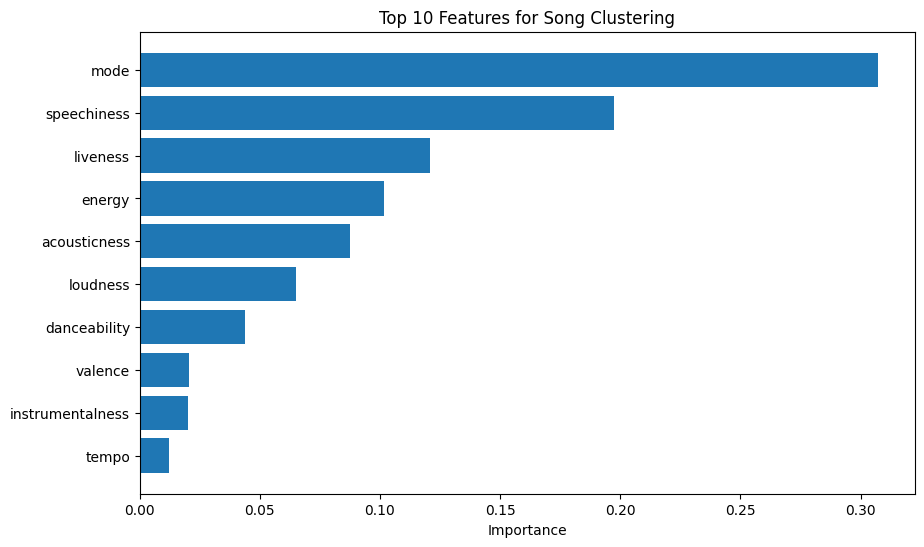

In [15]:
# Most important features for clustering
from sklearn.ensemble import RandomForestClassifier

# Train classifier to predict cluster (reveals feature importance)
rf = RandomForestClassifier(random_state=42)
rf.fit(X_scaled, clusters)

feature_importance = pd.DataFrame({
    'feature': available_features,
    'importance': rf.feature_importances_
}).sort_values('importance', ascending=False)

print("\n🎯 Most Important Features for Clustering:")
print(feature_importance.head(10))

# Visualize
plt.figure(figsize=(10, 6))
plt.barh(feature_importance['feature'][:10], 
         feature_importance['importance'][:10])
plt.xlabel('Importance')
plt.title('Top 10 Features for Song Clustering')
plt.gca().invert_yaxis()
plt.show()